<a href="https://colab.research.google.com/github/Tensor-Reloaded/AI-Learning-Hub/blob/main/resources/advanced_pytorch/AdvancedTensorOperations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install timed-decorator

In [2]:
import torch
from torch import Tensor
import torch.utils.benchmark as benchmark
from timed_decorator.simple_timed import timed
from typing import Tuple
from functools import partial
import matplotlib.pyplot as plt


# Advanced tensor operations

## Batching guidelines

PyTorch works with batches. Use batched operations, it's (almost) always better than using single items.

In [3]:
# Example, good
def batched_processing(x):
    pass  # Do stuff with batch x


def single_item_processing(x):
    return batched_processing([x])

Doing single item processing disables vectorization and built-in parallelization.

In [4]:
# Example, bad
def single_item_processing(x):
    pass  # Do stuff with element x


def batched_processing(x):
    return [single_item_processing(i) for i in x]

## Example 1

In [5]:
@timed(show_args=True, use_seconds=True)
def single_item_exp(batch: Tensor):
    for x in batch:
        x.exp()


@timed(show_args=True, use_seconds=True)
def batched_exp(batch: Tensor):
    batch.exp()


tensor_1 = torch.rand((5000))
tensor_2 = torch.rand((10000))
tensor_3 = torch.rand((20000))

print("O(n)")
single_item_exp(tensor_1)
single_item_exp(tensor_2)
single_item_exp(tensor_3)

print("\nWe do not see the linear increase until we reach the hardware parallelization capacity")
batched_exp(tensor_1)
batched_exp(tensor_2)
batched_exp(tensor_3)
batched_exp(torch.rand((20000 * 10)))
batched_exp(torch.rand((20000 * 100)))

del tensor_1, tensor_2, tensor_3

O(n)
single_item_exp(CpuTensor[5000]) -> total time: 0.199104798s
single_item_exp(CpuTensor[10000]) -> total time: 0.062908218s
single_item_exp(CpuTensor[20000]) -> total time: 0.120265149s

We do not see the linear increase until we reach the hardware parallelization capacity
batched_exp(CpuTensor[5000]) -> total time: 0.000115038s
batched_exp(CpuTensor[10000]) -> total time: 0.000145567s
batched_exp(CpuTensor[20000]) -> total time: 0.000147085s
batched_exp(CpuTensor[200000]) -> total time: 0.000345798s
batched_exp(CpuTensor[2000000]) -> total time: 0.006965299s


## Example 2

In [6]:
@timed(show_args=True, use_seconds=True)
def single_item_softmax(batch: Tensor):
    for x in batch:
        x.softmax(dim=0)


@timed(show_args=True, use_seconds=True)
def batched_softmax(batch: Tensor):
    batch.softmax(dim=1)


tensor_1 = torch.rand((1000, 500))
tensor_2 = torch.rand((5000, 500))
tensor_3 = torch.rand((10000, 500))

single_item_softmax(tensor_1)
single_item_softmax(tensor_2)
single_item_softmax(tensor_3)

batched_softmax(tensor_1)
batched_softmax(tensor_2)
batched_softmax(tensor_3)

assert torch.isclose(tensor_1[0].softmax(dim=0), tensor_1.softmax(dim=1)[0]).all()

del tensor_1, tensor_2, tensor_3

single_item_softmax(CpuTensor[1000, 500]) -> total time: 0.019784599s
single_item_softmax(CpuTensor[5000, 500]) -> total time: 0.035875833s
single_item_softmax(CpuTensor[10000, 500]) -> total time: 0.074776871s
batched_softmax(CpuTensor[1000, 500]) -> total time: 0.001094279s
batched_softmax(CpuTensor[5000, 500]) -> total time: 0.012464971s
batched_softmax(CpuTensor[10000, 500]) -> total time: 0.027432721s


## Inplace operations

General guideline: Most inplace operations are faster because they avoid memory allocation.
However, the PyTorch Autograd Engine might complain when asked to compute gradients for inplace operations. So always check if the forward and backward step works when using inplace operations.

In [7]:
@timed(show_args=True, use_seconds=True)
def add(x: Tensor, y: Tensor):
    x = x + y


@timed(show_args=True, use_seconds=True)
def add_(x: Tensor, y: Tensor):
    x += y


@timed(show_args=True, use_seconds=True)
def abs(x: Tensor):
    x = x.abs()


@timed(show_args=True, use_seconds=True)
def abs_(x: Tensor):
    x.abs_()


tensor_1 = torch.rand((1000, 5000))
tensor_2 = torch.rand((1000, 5000))


add(tensor_1, tensor_2)
add_(tensor_1, tensor_2)
abs(tensor_1)
abs_(tensor_1)

del tensor_1, tensor_2

add(CpuTensor[1000, 5000], CpuTensor[1000, 5000]) -> total time: 0.014864555s
add_(CpuTensor[1000, 5000], CpuTensor[1000, 5000]) -> total time: 0.005720653s
abs(CpuTensor[1000, 5000]) -> total time: 0.004369313s
abs_(CpuTensor[1000, 5000]) -> total time: 0.002285553s


## Case study



In [8]:
@timed(show_args=True, use_seconds=True)
def complex_operations(x: Tensor, y: Tensor) -> Tensor:
    # Both x and y are [B, N, M]
    norms_x = x.norm(p=2, dim=(1, 2))
    norms_y = y.norm(p=2, dim=(1, 2))

    mean_x = norms_x.mean()
    std_x = norms_x.std()
    mean_y = norms_y.mean()
    std_y = norms_y.std()

    mask = torch.logical_and(
        (norms_x - mean_x).abs() < std_x,
        (norms_y - mean_y).abs() < std_y
    )

    return torch.where(mask.view(-1, 1, 1), x, y)


@timed(show_args=True, use_seconds=True)
@torch.compile
def complex_operations_compiled(x: Tensor, y: Tensor) -> Tensor:
    # Both x and y are [B, N, M]
    norms_x = x.norm(p=2, dim=(1, 2))
    norms_y = y.norm(p=2, dim=(1, 2))

    std_x, mean_x = torch.std_mean(norms_x)
    std_y, mean_y = torch.std_mean(norms_y)

    mask = torch.logical_and(
        (norms_x - mean_x).abs() < std_x,
        (norms_y - mean_y).abs() < std_y
    )

    return torch.where(mask.view(-1, 1, 1), x, y)


In [9]:
tensor_1 = torch.rand((10000, 100, 200))
tensor_2 = torch.rand((10000, 100, 200))
complex_operations(tensor_1, tensor_2)

print("\nWe call traced twice because the first call is slower")
complex_operations_compiled(tensor_1, tensor_2)
_ = complex_operations_compiled(tensor_1, tensor_2)

complex_operations(CpuTensor[10000, 100, 200], CpuTensor[10000, 100, 200]) -> total time: 1.166704345s

We call traced twice because the first call is slower
complex_operations_compiled(CpuTensor[10000, 100, 200], CpuTensor[10000, 100, 200]) -> total time: 23.244825378s
complex_operations_compiled(CpuTensor[10000, 100, 200], CpuTensor[10000, 100, 200]) -> total time: 0.708892329s


In [10]:
tensor_1_cuda = tensor_1.cuda()
tensor_2_cuda = tensor_2.cuda()
complex_operations(tensor_1_cuda, tensor_2_cuda)
print()
complex_operations_compiled(tensor_1_cuda, tensor_2_cuda)
_ = complex_operations_compiled(tensor_1_cuda, tensor_2_cuda)


complex_operations(CudaTensor[10000, 100, 200], CudaTensor[10000, 100, 200]) -> total time: 0.215865668s

complex_operations_compiled(CudaTensor[10000, 100, 200], CudaTensor[10000, 100, 200]) -> total time: 2.259044913s
complex_operations_compiled(CudaTensor[10000, 100, 200], CudaTensor[10000, 100, 200]) -> total time: 0.015721871s


We use timeit for repeating an experiment multiple times

In [11]:
%%timeit
complex_operations.__wrapped__(tensor_1, tensor_2)

830 ms ± 144 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [12]:
%%timeit
complex_operations_compiled.__wrapped__(tensor_1, tensor_2)

678 ms ± 74.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [13]:
%%timeit
complex_operations.__wrapped__(tensor_1_cuda, tensor_2_cuda)

13.9 ms ± 2.03 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [14]:
%%timeit
complex_operations_compiled.__wrapped__(tensor_1_cuda, tensor_2_cuda)

15.2 ms ± 437 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [15]:
del tensor_1, tensor_2, tensor_1_cuda, tensor_2_cuda

### Benchmarking with pytorch

In [16]:
def all_finite(x):
    return torch.isfinite(x).all()

In [37]:
SIZES = [10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]


def run_benchmark(device):
    eager = all_finite
    compiled = torch.compile(all_finite)

    measurements = []
    plot_data = {"Eager": [], "Compiled": []}

    for size in SIZES:
        x = torch.randn(size, device=device)

        expected = eager(x)
        actual = compiled(x)
        assert torch.equal(expected, actual)

        for name, fn in [("Eager", eager), ("Compiled", compiled)]:
            measurement = benchmark.Timer(
                stmt="fn(x)",
                globals={"fn": fn, "x": x},
                label=f"all_finite [{device.upper()}]",
                sub_label=f"{size:,} elements",
                description=name,
            ).blocked_autorange(min_run_time=1.0)

            measurements.append(measurement)
            plot_data[name].append(measurement.median * 1e6)

    return measurements, plot_data


def plot_results(device, data):
    for name, times in data.items():
        plt.plot(SIZES, times, marker="o", label=name)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Number of elements")
    plt.ylabel("Median execution time [µs]")
    plt.title(f"torch.isfinite(x).all() on {device.upper()}")
    plt.grid(True, which="both", linestyle=":", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [38]:
measurements, cpu_data = run_benchmark("cpu")

comparison = benchmark.Compare(measurements)
comparison.trim_significant_figures()
comparison.colorize()
comparison.print()

[--------------- all_finite [CPU] ---------------]
                            |  Eager   |  Compiled
1 threads: ---------------------------------------
      10,000 elements       |      40  |      40  
      100,000 elements      |     400  |      50  
      1,000,000 elements    |    5800  |     300  
      10,000,000 elements   |   50000  |    2600  
      100,000,000 elements  |  600000  |   34000  

Times are in microseconds (us).



In [39]:
measurements, cuda_data = run_benchmark("cuda")

comparison = benchmark.Compare(measurements)
comparison.trim_significant_figures()
comparison.colorize()
comparison.print()

[-------------- all_finite [CUDA] --------------]
                            |  Eager  |  Compiled
1 threads: --------------------------------------
      10,000 elements       |     70  |     100  
      100,000 elements      |     80  |      68  
      1,000,000 elements    |     89  |     147  
      10,000,000 elements   |    891  |    1440  
      100,000,000 elements  |   8800  |   14500  

Times are in microseconds (us).



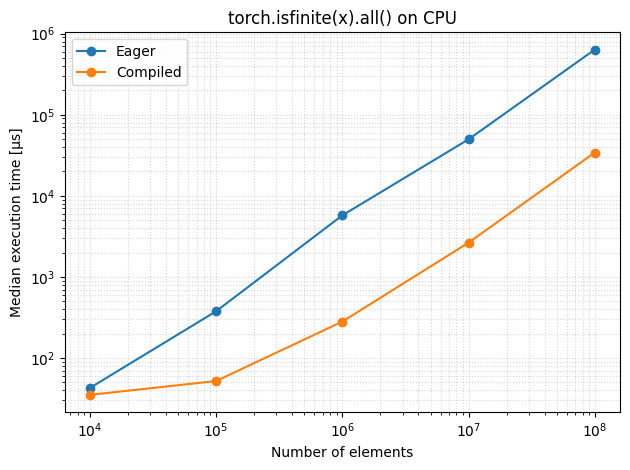

In [40]:
plot_results("cpu", cpu_data)

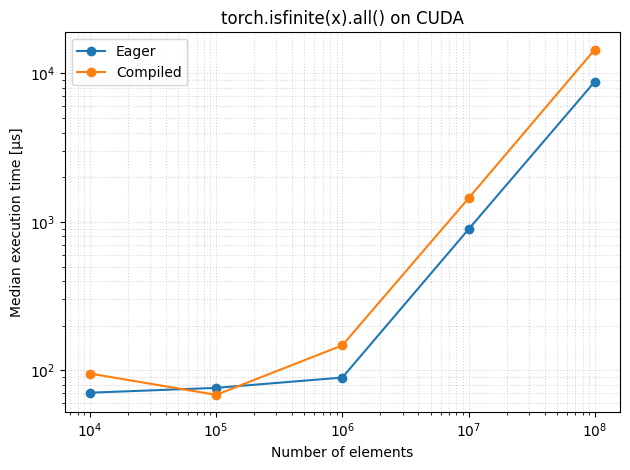

In [41]:
plot_results("cuda", cuda_data)

In [42]:
from torch.profiler import profile, ProfilerActivity


def run(device, compiled):
    x = torch.randn(1_000_000, device=device)
    compiled_fn = torch.compile(all_finite)

    # Compile and warm up before profiling.
    compiled_fn(x)

    activities = [ProfilerActivity.CPU]
    if device == "cuda":
        activities.append(ProfilerActivity.CUDA)

    with profile(activities=activities) as prof:
        if compiled:
            compiled_fn(x)
        else:
            all_finite(x)

    sort_by = "cuda_time_total" if device == "cuda" else "cpu_time_total"

    print(
        prof.key_averages().table(
            sort_by=sort_by,
            row_limit=15,
        )
    )

In [43]:
run("cpu", False)

-----------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-----------------------  ------------  ------------  ------------  ------------  ------------  ------------  
         aten::isfinite         0.50%      32.130us        85.31%       5.535ms       5.535ms             1  
              aten::abs        30.30%       1.966ms        60.00%       3.893ms       1.946ms             2  
               aten::ne        24.28%       1.576ms        24.74%       1.605ms       1.605ms             1  
               aten::eq        20.36%       1.321ms        20.36%       1.321ms       1.321ms             1  
              aten::all        14.61%     947.765us        14.69%     953.290us     953.290us             1  
              aten::mul         9.33%     605.159us         9.33%     605.159us     605.159us             1  
          

In [44]:
run("cpu", True)

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                             Torch-Compiled Region: 1/1        26.34%      91.980us        91.17%     318.348us     318.348us             1  
## Call CompiledFxGraph fg5iivp6rytq7apvkwzsstr7e6cm...        56.64%     197.776us        56.64%     197.776us     197.776us             1  
                               TorchDynamo Cache Lookup         8.83%      30.822us         8.83%      30.822us      30.822us             1  
                                      Pregraph bytecode         4.27%      14.910us         4.27%      14.910us      14.910us             1  
      

In [45]:
run("cuda", False)

---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
             aten::isfinite         1.44%      21.345us        94.72%       1.409ms       1.409ms             1  
                  aten::abs         5.37%      79.829us       169.14%       2.515ms       1.258ms             2  
                aten::empty         1.50%      22.323us         1.50%      22.323us      22.323us             1  
              aten::resize_         0.71%      10.601us         0.71%      10.601us      10.601us             1  
    Activity Buffer Request        35.02%     520.825us        35.02%     520.825us     520.825us             1  
           cudaLaunchKernel        46.41%     690.154us        46.41%     690.154us     

In [46]:
run("cuda", True)

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                               TorchDynamo Cache Lookup         1.01%      29.134us         1.01%      29.134us      29.134us             1  
                             Torch-Compiled Region: 1/2         3.41%      98.244us        97.60%       2.816ms       2.816ms             1  
                                      Pregraph bytecode         0.70%      20.259us         0.70%      20.259us      20.259us             1  
                 AOTDispatcher Runtime Wrapper Prologue         0.50%      14.507us         0.50%      14.507us      14.507us             1  
## Cal

## Excercises

### Excercise 1

Input: two boolean two-dimensional tensors, with shape [N, M], which represent a segmentation prediction and a segmentation ground truth.


In [22]:
x1 = torch.rand((10, 8)) < 0.5
x2 = torch.rand((10, 8)) < 0.5
x1, x2

(tensor([[False, False, False, False, False,  True, False, False],
         [False,  True,  True,  True, False, False, False,  True],
         [False, False,  True, False, False, False, False, False],
         [False,  True, False, False,  True, False, False, False],
         [False, False, False, False, False, False, False,  True],
         [ True, False, False,  True, False,  True,  True, False],
         [False,  True, False,  True,  True,  True,  True,  True],
         [False, False, False,  True, False, False, False, False],
         [False, False,  True, False,  True, False,  True,  True],
         [False, False,  True,  True, False, False, False,  True]]),
 tensor([[ True,  True, False,  True, False,  True,  True, False],
         [ True, False,  True,  True, False, False, False, False],
         [ True,  True, False, False,  True,  True,  True, False],
         [ True, False, False,  True,  True, False,  True,  True],
         [ True, False, False, False,  True,  True, False, F

a) Calculate the number of $TP$.

In [23]:
def get_tp(x: Tensor, y: Tensor) -> int:
    pass  # Implement here

b) Calculate the number of $TP, FP, FN, TN$.

In [24]:
def get_tp_fp_fn_tn(x: Tensor, y: Tensor) -> Tuple[int, int, int, int]:
    pass

c) Calculate the dice score (https://en.wikipedia.org/wiki/S%C3%B8rensen%E2%80%93Dice_coefficient).

In [25]:
def dice_score(x: Tensor, y: Tensor) -> Tensor:
    pass

### Excercise 2

Write a function that calculates the batched euclidean distance between two tensors of shape [B1, N], [B2, N], where B1 and B2 are the batch dimensions and N is the number of features.

In [26]:
def batched_euclidean_distance(x: Tensor, y: Tensor) -> Tensor:
    pass  # your implementation here


a = torch.rand((10, 8))
b = torch.rand((12, 8))
batched_euclidean_distance(a, b)

Start with writing a function that computs the euclidian instance between two vectors:


In [27]:
def single_element_euclidian_distance(x_i: Tensor, y_i: Tensor) -> Tensor:
    pass  # your implementation here

### Excercise 3:

Working with the test_image.jpg

In [28]:
!wget https://github.com/Tensor-Reloaded/Advanced-Topics-in-Neural-Networks-Template-2024/blob/main/Lab01/test_image.jpg?raw=true -O test_image.jpg

--2026-09-25 13:47:36--  https://github.com/Tensor-Reloaded/Advanced-Topics-in-Neural-Networks-Template-2024/blob/main/Lab01/test_image.jpg?raw=true
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/Tensor-Reloaded/Advanced-Topics-in-Neural-Networks-Template-2024/raw/refs/heads/main/Lab01/test_image.jpg [following]
--2026-09-25 13:47:37--  https://github.com/Tensor-Reloaded/Advanced-Topics-in-Neural-Networks-Template-2024/raw/refs/heads/main/Lab01/test_image.jpg
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Tensor-Reloaded/Advanced-Topics-in-Neural-Networks-Template-2024/refs/heads/main/Lab01/test_image.jpg [following]
--2026-09-25 13:47:37--  https://raw.githubusercontent.com/Tensor-Reloaded/Advanced-Topics-in-Neural-Networks-Template-2024/r

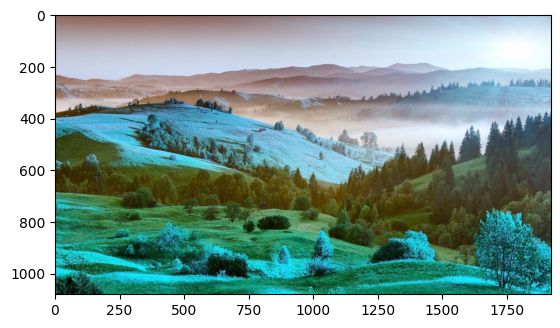

In [29]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2 as cv

img = torch.from_numpy(cv.imread("test_image.jpg"))
plt.imshow(img)
plt.show()

a) Transform the image from the BGR format to the RGB format and display it.

TypeError: Image data of dtype object cannot be converted to float

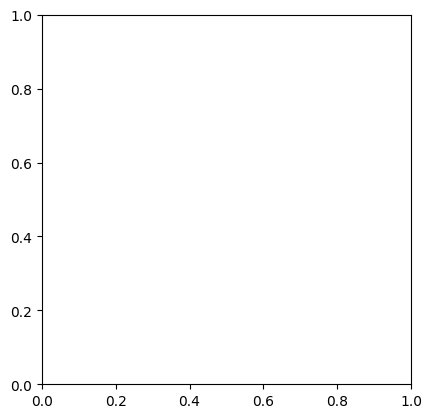

In [30]:
img_rgb = ...  # your code here


plt.imshow(img_rgb)
plt.show()

Create the following image!
```
cloned_img = img.clone()
...
plt.imshow(cloned_img)
plt.show()
```
Expected result:

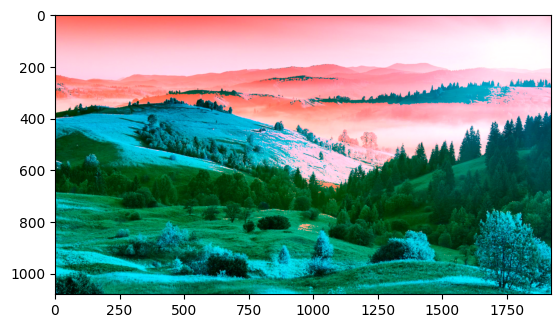

In [ ]:
# your code here

b) Transform the image to grayscale using tensor operations.

In [ ]:
img_grayscale = ...  # your code here


plt.imshow(img_grayscale)
plt.show()

c) Crop the top-left corner of the image and display it.

In [ ]:
img_cropped = ...  # your code here


plt.imshow(img_cropped)
plt.show()

d) Set all green pixels to red using basic pytorch operations.

In [ ]:
img_red = ...  # your code here


plt.imshow(img_red)
plt.show()

e) Add a random noise matrix to the top-left corner of the image, clip the values to 0 and 255 and display it.

In [ ]:
img_noise = ...  # your code here


plt.imshow(img_noise)
plt.show()

f) Write a function that rotates the image 90 degrees and display the rotated image

In [ ]:
def rotate90(x: Tensor) -> Tensor:
    pass

plt.imshow(rotate90(img))
plt.show()

---

| All     | [advanced_pytorch/](https://github.com/Tensor-Reloaded/AI-Learning-Hub/blob/main/resources/advanced_pytorch) |
|---------|-- |
| Current | [Advanced Tensor Operations](https://github.com/Tensor-Reloaded/AI-Learning-Hub/blob/main/resources/advanced_pytorch/AdvancedTensorOperations.ipynb) |